<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/finding-zeros-JeremyDail/blob/main/19_Random_walk_statistics_and_binomial_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 19: Random Walk Statistics and the Binomial Distribution

## Learning Objectives
By the end of this module you should be able to:
1. Slice a 2D NumPy array to extract particle positions at a specific timestep
2. Plot normalized histograms and interpret them as probability distributions evolving in time
3. Compute ensemble mean and standard deviation using `np.mean` and `np.std` with the correct `axis` argument
4. Explain qualitatively why the spread of random-walk particles grows as $\\sqrt{N}$
5. Simulate the binomial distribution with `rng.binomial` and describe its shape and parameters
6. Convert a binomial sample to a random-walk final-position distribution and verify the $\\sqrt{N}$ spread

---

## Background

In Module 18 we built increasingly efficient code for simulating many 1D random-walk particles simultaneously. The final version, `rw_multi2`, generates a 2D array of shape `(Np, Nstep)` where each row is one particle's full trajectory.

Now we shift attention from *how to simulate* to *what the simulation tells us*. Two key questions:

1. **How does the position distribution of an ensemble of particles change over time?**  
   Particles start clustered at the origin, then spread outward. The distribution at step $n$ is approximately Gaussian with mean $\\mu = 0$ and standard deviation $\\sigma = \\sqrt{n}$.

2. **Why $\\sqrt{n}$?**  
   Each step is an independent $\\pm 1$ coin flip. The final position after $n$ steps is the sum of $n$ independent random variables — the situation described by the **binomial distribution** — and the standard deviation of that sum scales as $\\sqrt{n}$.

Understanding this connection between random walk, the binomial distribution, and ultimately the **Central Limit Theorem** is the goal of this module.

---

## Setup: Rebuild `rw_multi2`

We start from the fully-vectorized multi-particle random-walk function from Module 18. Run the cell below — we will reuse `rmulti` throughout this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rw_multi2(Np, N):
    N  = int(N)
    Np = int(Np)
    rng = np.random.default_rng()
    hop    = rng.choice([-1, 1], [Np, N])
    rmulti = np.cumsum(hop, axis=1)
    return rmulti

rmulti = rw_multi2(1e4, 1e3)   # 10 000 particles, 1 000 steps each
print("Shape of rmulti:", rmulti.shape)  # should be (10000, 1000)

Shape of rmulti: (10000, 1000)


---

## Part 1: Position Distributions at Different Timesteps

The 2D array `rmulti` has shape `(Np, Nstep)`. Each **column** contains the positions of all $N_p$ particles at a single timestep. Slicing a column gives a snapshot of the ensemble at that moment — for example, `rmulti[:, -1]` gives positions at the last step, and `rmulti[:, 50]` gives positions at step 50.

> **Q1.1** — Plot three normalized histograms on the same figure: particle positions at step index `50` (early), `500` (middle), and `-1` (final). Use `density=True` and `bins=20`. Add a legend.

> **Q1.2** — Describe how the distribution changes between the three snapshots. What stays the same? What changes?

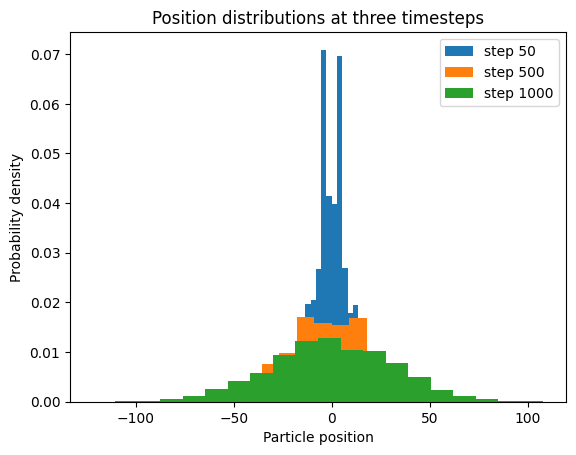

In [2]:
plt.figure()
for step, label in zip([50, 500, -1], ['step 50', 'step 500', 'step 1000']):
    plt.hist(rmulti[:, step], density=True, bins=20, label=label)

plt.xlabel('Particle position')
plt.ylabel('Probability density')
plt.title('Position distributions at three timesteps')
plt.legend()
plt.show()

*Your answers to Q1.1 and Q1.2:*
Q1.1: Three histograms were plotted on the same figure for the particle positions at step 50, 500, and 1000. The parameter density=true was used so each histogram represents a probability density. bins = 20 was used to group the data. A legend was added to distinguish the three time steps.
Q1.2: As the # of steps increase, the distribution becomes wider and spread out. At step 50, most of the particles are clustered close to zero. At step 500, the distribution is wider. The final step spreads out even more.
The distribution remains centered around zero and keeps a bell-shaped form. The spread of the distribution changes as it increases over time as particles diffuse from the origin.

---

## Part 2: Ensemble Mean and Standard Deviation

Instead of snapshots, we can track the **mean** and **standard deviation** of all particle positions *at every step* using `np.mean` and `np.std` with an `axis` argument.

`rmulti` has shape `(Np, Nstep)`. Averaging along `axis=0` collapses the particle dimension and returns one value per step.

> **Q2.1** — Compute `means` and `stds`: arrays of length `Nstep` giving the mean and standard deviation across all particles at each step.

> **Q2.2** — What value do you expect `means` to hover near? Why does the random walk have zero mean regardless of how many steps are taken?

In [3]:
means = np.mean(rmulti, axis=0)
stds  = np.std(rmulti, axis=0)

print(f"Mean position at final step:    {means[-1]:.3f}")
print(f"Std of positions at final step: {stds[-1]:.2f}")

Mean position at final step:    -0.298
Std of positions at final step: 31.93


*Your answers to Q2.1 and Q2.2:*
Q2.1: The mean and standard dev were computed by taking the average across all particles at each step. This gives two arrays: one for the mean position and one for the stan dev of the particle positions as the walk evolves.
Q2.2: The mean should be near zero because each step is equally likely to be +1 or -1, so there's no bias in either direction. Over many particles, the positive and negative displacements cancel out on average.
The random walk has zero mean regardless of the number of steps taken because the value of each individual step is expected to be zero. Adding together a lot of these zero-mean steps still gives an expected mean of zero.

---

## Part 3: Visualizing the Spread

> **Q3.1** — On a single figure, plot:
> - 20 individual particle trajectories (rows 0–19 of `rmulti`)
> - `means` in black
> - `stds` in blue
>
> Label the axes and add a descriptive title.

> **Q3.2** — Does the standard deviation grow *linearly* (constant speed), *faster*, or *slower* than linear? Make a qualitative judgment from the plot before we verify it analytically.

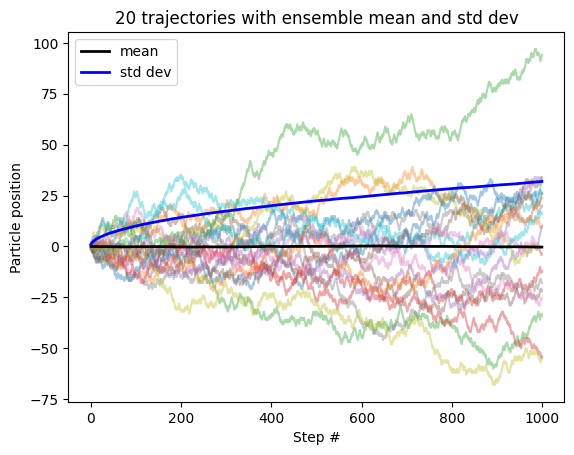

In [4]:
plt.figure()
for i in range(20):
    plt.plot(rmulti[i], alpha=0.4)
plt.plot(means, 'k-', label='mean',    linewidth=2)
plt.plot(stds,  'b-', label='std dev', linewidth=2)
plt.xlabel('Step #')
plt.ylabel('Particle position')
plt.title('20 trajectories with ensemble mean and std dev')
plt.legend()
plt.show()

*Your answers to Q3.1 and Q3.2:*
Q3.1: Done
Q3.2: The stan dev grows slower than linear. From the plot, it increases but doesn't form a straight line. It curves downard slightly and this suggests it grows slower than a lienar function. This follows the idea that the stan dev is a square root relationship instead of a linear one.

---

## Part 4: Verifying the $\\sqrt{N}$ Law

The theoretical prediction for the spread of a 1D random walk is

$$\\sigma(n) = \\sqrt{n}$$

where $n$ is the step number.

> **Q4.1** — Create a step array `n = np.arange(1, 1001)` and overlay the curve $\\sqrt{n}$ on the previous figure as a dashed red line. How well does theory match simulation?

> **Q4.2** — What does the $\\sqrt{n}$ growth law imply about how quickly particles spread? To double the spread, how many more steps are needed?

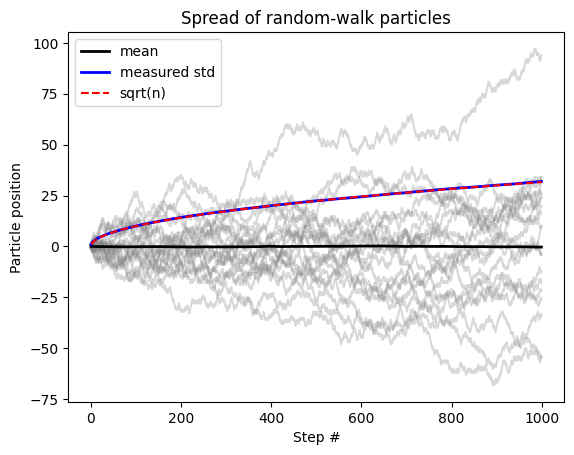

In [5]:
n = np.arange(1, 1001)

plt.figure()
for i in range(20):
    plt.plot(rmulti[i], alpha=0.3, color='gray')
plt.plot(means, 'k-',   label='mean',          linewidth=2)
plt.plot(stds,  'b-',   label='measured std',  linewidth=2)
plt.plot(n, np.sqrt(n), 'r--', label='sqrt(n)')
plt.xlabel('Step #')
plt.ylabel('Particle position')
plt.title('Spread of random-walk particles')
plt.legend()
plt.show()

*Your answers to Q4.1 and Q4.2:*
Q4.1: the theoretical curve matches the simulation very well. The measured standard dev follows the sqrt(n) line, especially at larger step numbers.
Q4.2: The sqrt(n) growth law implies particles spread slowly over time. The spread doesn't increase linearly. It increases at a decreasing rate.
To double the spread, you need four times as many steps.

---

## Part 5: The Binomial Distribution

### Why $\\sqrt{n}$? — A coin-flip model

Every step in a 1D random walk is equivalent to flipping a fair coin: heads $= +1$, tails $= -1$.  
After $n$ flips, the number of heads follows the **binomial distribution**.

NumPy samples from it with:

```python
rng.binomial(n, p, N)
```

- `n` — number of coin flips per experiment  
- `p` — probability of heads  
- `N` — number of independent experiments

> **Q5.1** — Using `n=200, p=0.5`, generate `50` samples and plot a normalized histogram. Where is it centered? Is 50 samples enough to see the shape clearly?

> **Q5.2** — Repeat with `N=100000` samples. What well-known probability distribution does the smooth histogram resemble?

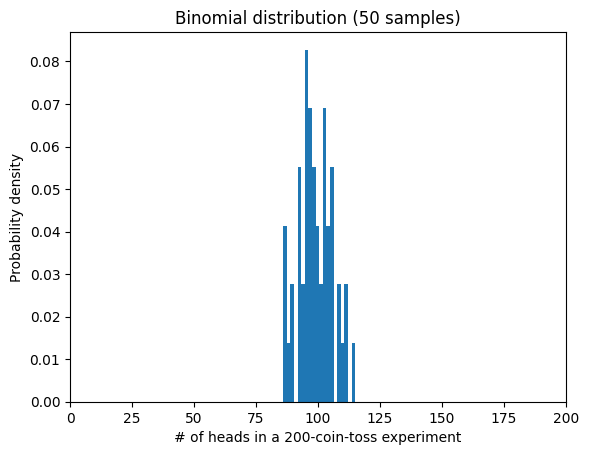

In [6]:
n = 200
p = 0.5

rng = np.random.default_rng()
sample_bino = rng.binomial(n, p, 50)

plt.figure()
plt.hist(sample_bino, density=True, bins=20)
plt.xlim(0, n)
plt.xlabel('# of heads in a 200-coin-toss experiment')
plt.ylabel('Probability density')
plt.title('Binomial distribution (50 samples)')
plt.show()

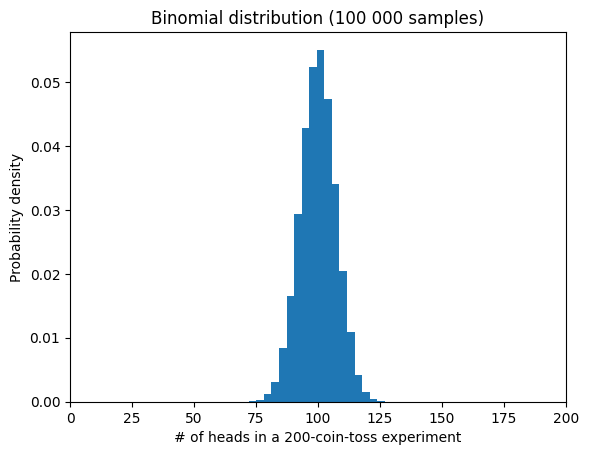

In [7]:
sample_bino = rng.binomial(n, p, 100000)

plt.figure()
plt.hist(sample_bino, density=True, bins=20)
plt.xlim(0, n)
plt.xlabel('# of heads in a 200-coin-toss experiment')
plt.ylabel('Probability density')
plt.title('Binomial distribution (100 000 samples)')
plt.show()

*Your answers to Q5.1 and Q5.2:*
Q5.1: The distribution is centered around 100, since the expected value of a binomial distribution is 100. The histogram only has 50 samples, thus is noisy and uneven as you need more data to see the true shape of the distribution.
Q5.2: When a number of samples gets increased to 100,000, the histogram becomes smooth and looks like a Gaussian distribution. This happens because of the central limit theorem. Binomial distribution approaches normal distribution when the number of trials is large.

---

## Part 6: Connecting the Binomial Distribution to Random Walk

If a particle flips $n$ coins and gets $k$ heads and $(n-k)$ tails, its final position is

$$x = k \\cdot (+1) + (n - k) \\cdot (-1) = 2k - n.$$

> **Q6.1** — Using `sample_bino` (100 000 samples, `n=200`), compute the random-walk final position `rw` from the formula above. Plot a normalized histogram with `xlim(-n, n)`.

> **Q6.2** — Add two vertical red lines at $x = \\pm\\sqrt{n}$ using `plt.axvline`. Do they align with the spread?

> **Q6.3** — The standard deviation of the binomial is $\\sqrt{n \\cdot p \\cdot (1-p)}$. For $p=0.5$, $n=200$, compute this. After converting to random-walk positions (multiply by 2), what is $\\sigma$? Does it equal $\\sqrt{n}$?

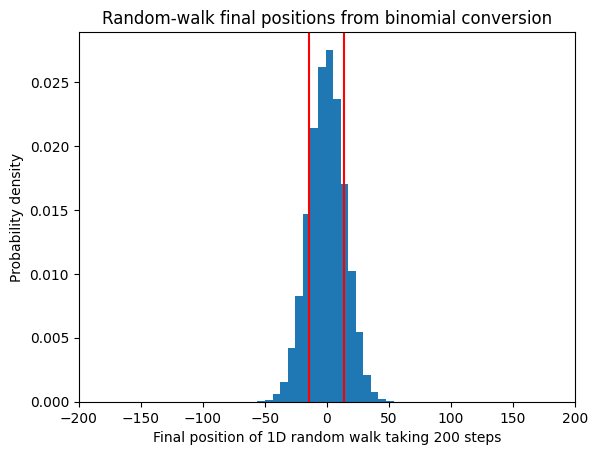

Measured std: 14.13
Expected std (sqrt(n)): 14.14


In [8]:
# Convert heads to random-walk positions
rw = sample_bino*(1) + (n - sample_bino)*(-1)

plt.figure()
plt.hist(rw, density=True, bins=20)
plt.xlim(-n, n)
plt.axvline(np.sqrt(n), color='r')
plt.axvline(-np.sqrt(n), color='r')
plt.xlabel('Final position of 1D random walk taking 200 steps')
plt.ylabel('Probability density')
plt.title('Random-walk final positions from binomial conversion')
plt.show()

print(f"Measured std: {np.std(rw):.2f}")
print(f"Expected std (sqrt(n)): {n**0.5:.2f}")

*Your answers to Q6.1, Q6.2, and Q6.3:*
Q6.1: Done
Q6.2: The vertical red lines should line up well with the spread of the histogram. They mark the approximate size of the stan dev for the random walk, so most data should be centered around that scale. They aren't at the edges, but do give a good estimate of the typical spread.
Q6.3:
stan dev = sqrt(200(0.5)(0.5)) = 7.07
rw = 2k - n
stan dev rw = 2sqrt(50) = 14.14
This is equal to sqrt(n) so for this random walk, standev = sqrt(n)

---

## Summary Questions

> **S1** — We used `axis=0` in `np.mean(rmulti, axis=0)`. Explain in plain language what dimension is being averaged over and what the resulting array represents.

> **S2** — Suppose we had a biased coin with $p=0.7$ (probability of $+1$ step). Would the mean position still be zero after many steps? What would the spread look like?

> **S3** — An ink drop in still water spreads diffusively. If after 1 second the cloud has radius $r$, how large will it be after 4 seconds?

> **S4** — The binomial distribution approaches a Gaussian as $n \\to \\infty$. This is a special case of the **Central Limit Theorem**. State the CLT in your own words and explain why random walk demonstrates it naturally.

*Your answers:*

**S1:** Using axis = 0 means we average down the columns at each step. For each step number, we take all particle positions at that step and compute their average. The resulting array shows how the mean position changes over time with one value for each step.

**S2:** The mean position would not be zero anymore. If p = 0.7, the steps of +1 happen more often than -1, so there is bias. The particle will drift in the positive direction over many steps. Thus the mean position will increase over time instead of staying zero. The spread will increase, but the distribution will be to the right and centered around a positive value.

**S3:** Diffusion is a square root relation ship. If time increases from 1 to 4 seconds, the cloud will be twice as large after 4 seconds.

**S4:** The CLT says when you add together many independent random variables, the result will look Gaussian, even if the original variables are not normally distributed.
A random walk demonstrates this because each step is a random variable. When you add up many steps, the distribution becomes Gaussian as the number of steps increases.